# 배송 시간에 영향을 주는 요인

In [1]:
# 표준 라이브러리
from pathlib import Path
import platform
from typing import List, Sequence, Any
import sys
import os

# 서드 파티 라이브러리
import pandas as pd
import numpy as np
from numpy.typing import ArrayLike

## 시각화 모듈
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.colors import Colormap
import seaborn as sns
import plotly.graph_objects as go

## 통계 모듈
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 머신러닝 모듈
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 로컬 모듈
sys.path.append(str(Path.cwd().parent))
sys.path.append(str(Path.cwd().parent / 'src'))
from src.plot import plot_box, plot_hist, plot_stacked_bar, plot_heatmap, plot_prop_bar, plot_mean_sem, plot_scatter_jitter
from src.utils import cramers_v, interpret_cramers_v, check_expected_frequencies, standardized_residuals
from src.utils import check_normality, check_homogeneity, calculate_eta_squared, calculate_epsilon_squared, perform_dunn_test, perform_gameshowell, perform_tukey_hsd
from src.utils import calculate_distance
from src.config import state_neighbors, state_region_map

DATA_DIR = Path('../data/processed')

In [2]:
system = platform.system()

if system == 'Windows':
    # Windows: 맑은 고딕 사용
    plt.rcParams['font.family'] = 'Malgun Gothic'
    
elif system == 'Darwin':  # Darwin = macOS
    # macOS: 애플 고딕 사용
    plt.rcParams['font.family'] = 'AppleGothic'
    
elif system == 'Linux':
    # Linux: 나눔 고딕 사용 (사전 설치 필요)
    # 터미널: sudo apt-get install -y fonts-nanum
    plt.rcParams['font.family'] = 'Freesentation'
    plt.rcParams['font.weight'] = 600  # SemiBold에 해당
    
else:
    print(f"알 수 없는 OS: {system}")

# 모든 OS 공통: 음수 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print(f"OS: {system}, 설정된 폰트: {plt.rcParams['font.family']}")

OS: Linux, 설정된 폰트: ['Freesentation']


In [3]:
pandas_kwargs = {
    'parse_dates': ['purchase_time', 'approved_time', 'carrier_delivered_time', 'delivered_time', 'estimated_delivery_time'],
    'date_format': '%Y-%m-%d %H:%M:%S',
    'memory_map': True
}

processed_data: pd.DataFrame = pd.read_csv(DATA_DIR / 'processed_data.csv', **pandas_kwargs)
processed_data

,order_id,order_qty,total_price,product_id,product_qty,category,review_score,price,freight_value,purchase_time,...,city_cust,state_cust,customer_id,customer_unique_id,seller_id,zip_code_sell,city_sell,state_sell,latitude_sell,longitude_sell
0,00e7ee1b050b8499577073aeb2a297a1,1,146.87,a9516a079e37a9c9c36b9b78b10169e8,1,가구·인테리어,4.0,124.99,21.88,2017-05-16 15:05:35,...,franca,SP,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
1,29150127e6685892b6eab3eec79f59c7,1,335.48,4aa6014eceb682077f9dc4bffebc05b0,1,생활용품,5.0,289.00,46.48,2018-01-12 20:48:24,...,sao bernardo do campo,SP,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,b8bc237ba3788b23da09c0f1f3a3288c,88303,itajai,SC,-26.920912,-48.684937
2,b2059ed67ce144a36e2aa97d2c9e9ad2,1,157.73,bd07b66896d6f1494f5b86251848ced7,1,가구·인테리어,5.0,139.94,17.79,2018-05-19 16:07:45,...,sao paulo,SP,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
3,951670f92359f4fe4a63112aa7306eba,1,173.30,a5647c44af977b148e0a3a4751a09e2e,1,가구·인테리어,5.0,149.94,23.36,2018-03-13 16:06:38,...,mogi das cruzes,SP,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
4,6b7d50bd145f6fc7f33cebabd7e49d0f,1,252.25,9391a573abe00141c56e38d84d7d5b3b,1,가구·인테리어,5.0,230.00,22.25,2018-07-29 09:51:30,...,campinas,SP,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,4a3ca9315b744ce9f8e9374361493884,14940,ibitinga,SP,-21.774868,-48.847152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100696,6760e20addcf0121e9d58f2f1ff14298,1,88.78,ccb4503d9d43d245d3b295d0544f988b,1,도서·미디어,4.0,74.90,13.88,2018-04-07 15:48:17,...,sao paulo,SP,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,527801b552d0077ffd170872eb49683b,17400,garca,SP,-22.210402,-49.662731
100697,9ec0c8947d973db4f4e8dcf1fbfa8f1b,1,129.06,9ede6b0570a75a4b9de4f383329f99ee,1,스포츠·레저,5.0,114.90,14.16,2018-04-04 08:20:22,...,taboao da serra,SP,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,3fd1e727ba94cfe122d165e176ce7967,14802,araraquara,SP,-21.775406,-48.168105
100698,fed4434add09a6f332ea398efd656a5c,1,56.04,7a5d2e1e131a860ae7d18f6fffa9d689,1,건강·뷰티,1.0,37.00,19.04,2018-04-08 20:11:50,...,fortaleza,CE,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,d9e7e7778b32987280a6f2cb9a39c57d,3304,sao paulo,SP,-23.545397,-46.581221
100699,e31ec91cea1ecf97797787471f98a8c2,1,711.07,f819f0c84a64f02d3a5606ca95edd272,1,패션·의류,5.0,689.00,22.07,2017-11-03 21:08:33,...,canoas,RS,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,4869f7a5dfa277a7dca6462dcf3b52b2,14840,guariba,SP,-21.369332,-48.225907


In [19]:
grouped = processed_data.drop_duplicates('order_id').groupby('customer_unique_id', as_index=False).agg(cnt_order=('order_id', 'nunique'))
repurchase_cond = grouped['cnt_order'] > 1
grouped[repurchase_cond].size / grouped.size * 100

2.972987781491425

In [41]:
# 리뷰 5점 한 고객 제외
exclude_only_5 = lambda x: not ((x['review_score'].nunique() == 1) & (x['review_score'].max() == '5.0'))
filtered_data = processed_data.groupby('customer_unique_id').filter(exclude_only_5)

In [50]:
filtered_data['review_score'].value_counts()

review_score
4.0     19193
1.0     11158
3.0      8501
2.0      3444
5.0       881
리뷰없음      877
Name: count, dtype: int64

## 파생변수 추가

In [51]:
# 배송 시간 관련
processed_data['approved_hours'] = ((processed_data['approved_time'] - processed_data['purchase_time']).dt.total_seconds() / 3600).round()
processed_data['carrier_delivered_hours'] = ((processed_data['carrier_delivered_time'] - processed_data['approved_time']).dt.total_seconds() / 3600).round()
processed_data['last_mile_hours'] = ((processed_data['delivered_time'] - processed_data['carrier_delivered_time']).dt.total_seconds() / 3600).round()
processed_data['delivered_hours'] = ((processed_data['delivered_time'] - processed_data['purchase_time']).dt.total_seconds() / 3600).round()
processed_data['delayed_days'] = (processed_data['delivered_time'] - processed_data['estimated_delivery_time']).dt.days

In [52]:
# 거리
processed_data['distance'] = calculate_distance(processed_data, 'latitude_cust', 'longitude_cust', 'latitude_sell', 'longitude_sell')

In [53]:
# 시계열 관련
processed_data['weekday_purchase'] = processed_data['purchase_time'].dt.dayofweek
processed_data['month_purchase'] = processed_data['purchase_time'].dt.month

In [54]:
review_data = processed_data[processed_data['review_score'] != '리뷰없음']
review_data = review_data.copy()
review_data['review_score'] = review_data['review_score'].astype(float).astype(int)
review_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99824 entries, 0 to 100700
Data columns (total 43 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   order_id                 99824 non-null  object        
 1   order_qty                99824 non-null  int64         
 2   total_price              99824 non-null  float64       
 3   product_id               99824 non-null  object        
 4   product_qty              99824 non-null  int64         
 5   category                 99824 non-null  object        
 6   review_score             99824 non-null  int64         
 7   price                    99824 non-null  float64       
 8   freight_value            99824 non-null  float64       
 9   purchase_time            99824 non-null  datetime64[ns]
 10  approved_time            99824 non-null  datetime64[ns]
 11  carrier_delivered_time   99824 non-null  datetime64[ns]
 12  delivered_time           99824 non-n

In [55]:
order_group = review_data.groupby('order_id').agg(
    승인시간 = ('approved_hours', 'max'),
    인수시간 = ('carrier_delivered_hours', 'max'),
    운송시간 = ('last_mile_hours', 'max'),
    총배송시간 = ('delivered_hours', 'max'),
    지연일 = ('delayed_days', 'max'),
    거리 = ('distance', 'max'),
    주문요일 = ('weekday_purchase', 'max'),
    주문월 = ('month_purchase', 'max'),
    무게 = ('weight_g', 'sum'),
    판매자주 = ('state_sell', 'max'),
    구매자주 = ('state_cust', 'max'),
    # 평점 = ('review_score', 'max')
)

order_group

,승인시간,인수시간,운송시간,총배송시간,지연일,거리,주문요일,주문월,무게,판매자주,구매자주
order_id,,,,,,,,,,,
00010242fe8c5a6d1ba2dd792cb16214,1.0,153.0,29.0,183.0,-9,302.215359,2,9,650.0,RJ,RJ
00018f77f2f0320c557190d7a144bdd3,0.0,195.0,193.0,389.0,-3,587.836868,2,4,30000.0,SP,SP
000229ec398224ef6ca0657da4fc703e,0.0,46.0,145.0,191.0,-14,307.364354,6,1,3050.0,MG,MG
00024acbcdf0a6daa1e931b038114c75,0.0,51.0,96.0,148.0,-6,287.899608,2,8,200.0,SP,SP
00042b26cf59d7ce69dfabb4e55b4fd9,0.0,284.0,319.0,603.0,-16,646.682058,5,2,3750.0,PR,SP
...,...,...,...,...,...,...,...,...,...,...,...
fffc94f6ce00a00581880bf54a75a037,38.0,8.0,371.0,417.0,-8,2756.382096,0,4,10150.0,SC,MA
fffcd46ef2263f404302a634eb57f7eb,66.0,4.0,156.0,226.0,-9,349.285447,5,7,8950.0,SP,PR
fffce4705a9662cd70adb13d4a31832d,24.0,46.0,45.0,115.0,-13,339.080498,0,10,967.0,PR,SP


In [70]:
delivery_data = order_group.copy()

delivery_data['승인비율'] = delivery_data['승인시간'] / delivery_data['총배송시간'] * 100
delivery_data['인수비율'] = delivery_data['인수시간'] / delivery_data['총배송시간'] * 100
delivery_data['운송비율'] = delivery_data['운송시간'] / delivery_data['총배송시간'] * 100
delivery_data['승인지연'] =  round(delivery_data['지연일'] * delivery_data['승인시간'] / delivery_data['총배송시간'])
delivery_data['인수지연'] =  round(delivery_data['지연일'] * delivery_data['인수시간'] / delivery_data['총배송시간'])
delivery_data['운송지연'] =  round(delivery_data['지연일'] * delivery_data['운송시간'] / delivery_data['총배송시간'])

In [71]:
delivery_data.describe()

,승인시간,인수시간,운송시간,총배송시간,지연일,거리,주문요일,주문월,무게,승인비율,인수비율,운송비율,승인지연,인수지연,운송지연
count,93491.000000,93491.000000,93491.000000,93491.000000,93491.000000,93491.000000,93491.000000,93491.000000,93491.000000,93491.000000,93491.000000,93491.000000,93491.000000,93491.000000,93491.000000
mean,9.490422,67.669476,224.009530,301.298285,-11.795050,601.567077,2.758159,6.021489,2223.740670,3.916350,25.482881,70.528747,-0.468644,-3.026997,-8.276219
std,19.166433,81.273824,208.653393,227.341080,10.031164,592.059493,1.966491,3.241824,4166.700008,8.359850,20.485041,21.279071,1.243405,3.569169,8.394007
min,0.000000,0.000000,0.000000,13.000000,-147.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-29.000000,-62.000000,-90.000000
25%,0.000000,22.000000,99.000000,163.000000,-17.000000,188.690313,1.000000,3.000000,300.000000,0.000000,9.325911,57.853905,0.000000,-4.000000,-13.000000
50%,0.000000,44.000000,171.000000,246.000000,-12.000000,435.656391,3.000000,6.000000,700.000000,0.000000,19.555556,75.862069,0.000000,-2.000000,-8.000000
75%,13.000000,86.000000,289.000000,377.000000,-7.000000,800.109960,4.000000,8.000000,1867.000000,4.196310,36.912752,87.500000,-0.000000,-1.000000,-4.000000
max,741.000000,3018.000000,4925.000000,5000.000000,188.000000,3399.318090,6.000000,12.000000,154200.000000,84.070796,100.000000,100.000000,10.000000,100.000000,185.000000


In [72]:
def plot_features(data: pd.DataFrame, features, colors):
    n = len(features)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3*n))
    
    for i in range(n):
        feature, color = features[i], colors[i]
        sns.boxplot(data, y=feature, color=color, ax=axes[i][0])
        axes[i][0].set_title('Box Plot')
        axes[i][0].grid(True, alpha=0.3)
        stats.probplot(data[feature], dist="norm", plot=axes[i][1])
        axes[i][1].set_title('Q-Q Plot')
        axes[i][1].grid(True, alpha=0.3)
        sns.histplot(data, x=feature, color=color, ax=axes[i][2])
        axes[i][2].set_title('히스토그램')
        axes[i][2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

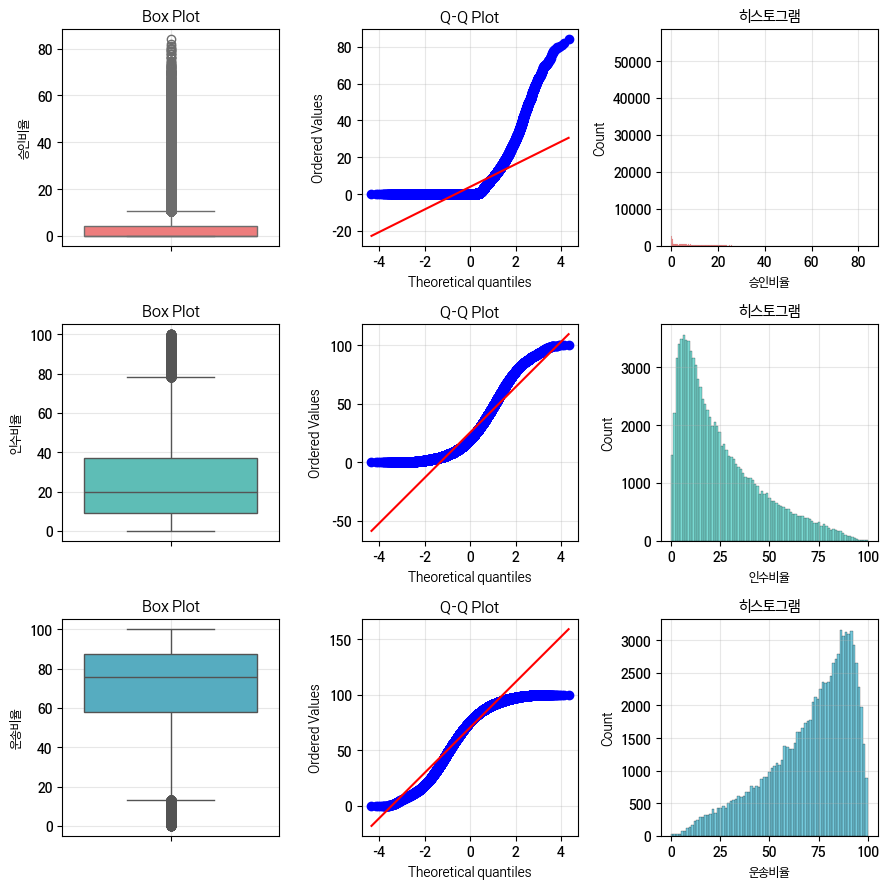

In [102]:
features = ['승인비율', '인수비율', '운송비율']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', "#96CEB4", '#FECA57']
plot_features(delivery_data, features, colors[:3])

In [113]:
cleaned_data = delivery_data[features].apply(lambda x: x[(x >= x.quantile(0.25)) & (x <= x.quantile(0.75))])
print(cleaned_data.mean().round(1))

승인비율     0.3
인수비율    20.7
운송비율    74.9
dtype: float64


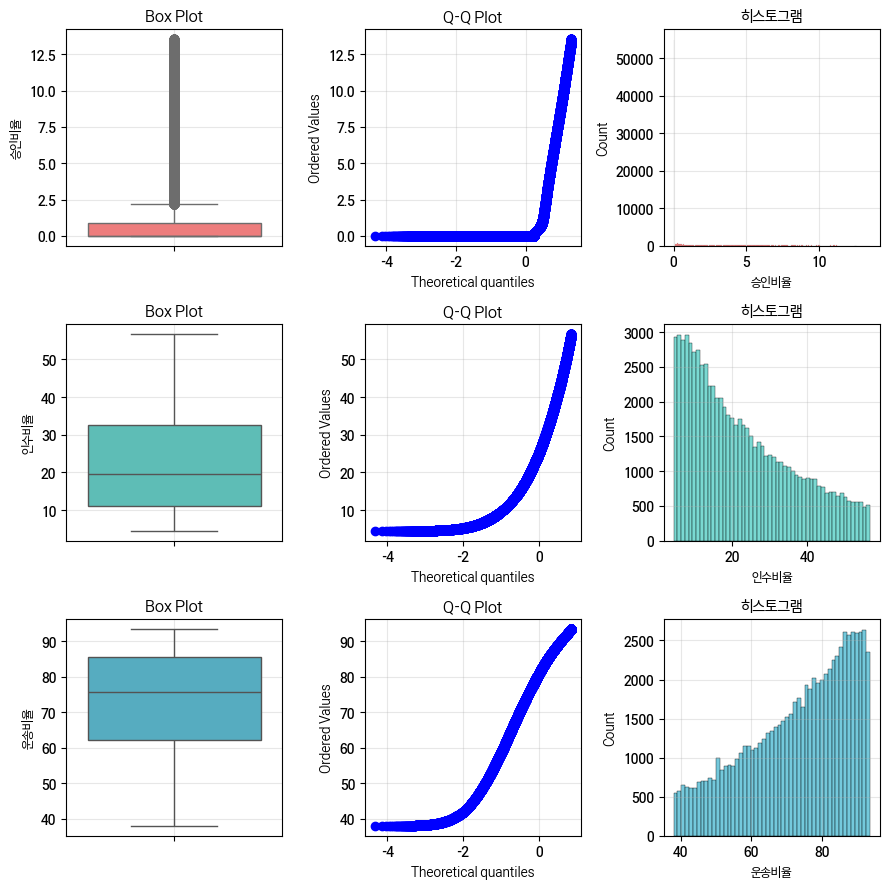

In [109]:
plot_features(cleaned_data, features, colors[:3])

In [115]:
def categorize_state_map(row: pd.Series):
    adj_cond = row['판매자주'] in state_neighbors[row['구매자주']]
    region_cond = state_region_map[row['구매자주']] == state_region_map[row['판매자주']]
    if row['구매자주'] == row['판매자주']:
        return '주 내부'
    elif adj_cond | region_cond:
        return '인근지역'
    else:
        return '광역권외'

delivery_data['distance_category'] = delivery_data.apply(categorize_state_map, axis=1)

In [116]:
# 실행 필요
distance_group = delivery_data.groupby('distance_category')['거리'].agg([
    'count', 'mean', 'median', 'std'
])
print(distance_group)

                   count         mean       median         std
distance_category                                             
광역권외               27865  1267.765398  1041.953165  637.573892
인근지역               31959   491.880339   468.230962  194.532076
주 내부               33667   154.300088    96.445993  149.137182


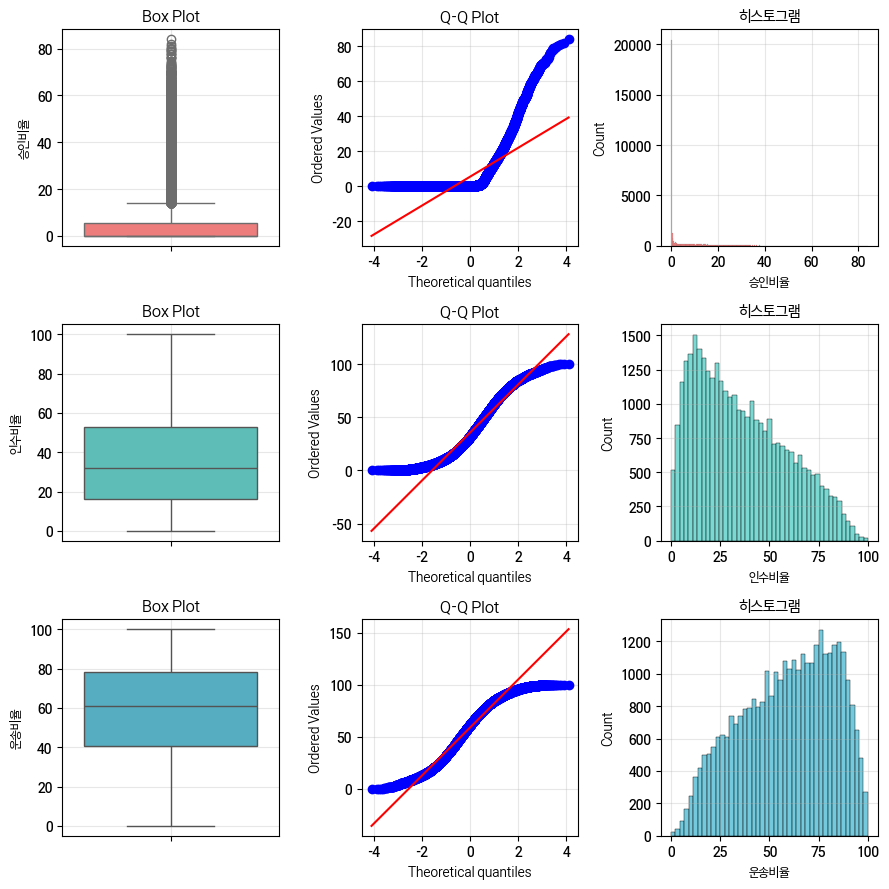

In [117]:
plot_features(delivery_data[delivery_data['distance_category'] == '주 내부'], features, colors[:3])

In [ ]:
nearby = delivery_data[delivery_data['판매자주'] == delivery_data['구매자주']]
faraway = delivery_data[delivery_data['판매자주'] != delivery_data['구매자주']]

In [ ]:
display(nearby.describe())
display(faraway.describe())